# The Term Premium — does 'extra yield for holding long bonds' tell you *when* to own them? 🏦
### Stripping a long-bond yield down to its risk-reward, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Term--premium_times_duration%3F: Mixed](https://img.shields.io/badge/Term--premium_times_duration%3F-Mixed-8b949e?style=flat-square)

A 10-year Treasury yield is really two things added together. One part is just *where everyone thinks short-term interest rates are heading* over the next decade. The other part is a bonus — the **term premium** — extra yield you demand for the *risk* of locking your money up for ten years instead of rolling short bills. Economists (the famous Adrian-Crump-Moench, or 'ACM', model) estimate that bonus and publish it.

The idea we test: when that bonus is **fat**, long bonds are generously paid for their risk, so you should *own duration* (buy the long-bond ETF, TLT); when it's **thin**, step aside. In short — can the term premium tell you *when* to hold long bonds?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from term_premium import data, strategy as st

def load_real():
    """Cache-first real daily tape (empty frame offline)."""
    try:
        return data.fetch_daily(fetch=False)
    except FileNotFoundError:
        return pd.DataFrame()

DF = load_real()
HAVE_REAL = not DF.empty
print("real term-premium tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(DF)} days, {DF.index[0].date()} -> {DF.index[-1].date()})")


real term-premium tape present: True (6009 days, 2002-07-31 -> 2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do fat-premium days precede higher long-bond returns? | **Yes — but only just.** Over the next month, the fattest-premium days earned **+0.43%** vs **+0.17%** for the thinnest — the *right* direction, a **+0.26%** gap. |
| Is that gap solid? | **No.** A shuffle test says a gap that size shows up **71%** of the time by pure chance. The signal is real-*ish* but far too faint to bank. |
| Does it always work? | **No — it depends on the decade.** It worked in 2002-2009, faded in 2010-2016, and went *backwards* in 2017-2021. |
| Could you trade it? | **No.** A timer that owns bonds on fat-premium days barely ties just-buying-and-holding, while flipping in and out ~10 times a year. |

> The term premium points the right way — the theory isn't wrong — but this cheap estimate of it is a whisper, not a shout, and the whisper changes its mind by decade.

## 1 · The claim

> *"The term premium — the compensation for holding long bonds — varies over time, and when it's high, long bonds subsequently earn more."* — Fama & Bliss (1987); Cochrane & Piazzesi (2005); Adrian, Crump & Moench (2013).

The intuition: a long bond's yield = (expected average short rate) + (term premium). The first part is just a forecast of Fed policy — no free lunch there. The *second* part is a risk reward, and decades of research say it **moves around** and is **predictable**. When it's fat, you're being paid well to bear duration risk; that's when to own it.

## 2 · So what?

If a term-premium estimate really timed long bonds, you'd have a clean rates signal: own TLT when the premium is fat, hold cash when it's thin — a bond-market market-timer. It would also validate the whole ACM/Cochrane-Piazzesi machinery on live retail data. The desk already looked at the raw curve *slope* ([132 Yield-Curve-Steepener](../../132-yield-curve-steepener/)); here we go one step deeper and strip out the *expectations* part to isolate the **premium** itself.

## 3 · How would we even know?

1. **Estimate the premium.** We can't reach the official ACM series with a free data feed, so we build the cheapest honest stand-in: the 10-year yield **minus** a slow moving average of the 3-month bill (a proxy for 'expected short rates'). What's left is the premium.
2. **Rank it.** Each day, how fat is today's premium versus its own last year? (0 = thinnest, 1 = fattest.)
3. **Sort forward returns.** Split days into five buckets by premium and compare how TLT did over the *next month*. The claim says the fattest bucket wins.

*Timing:* the premium at today's close forms the signal; we act at *tomorrow's* close (a one-day lag) — no peeking at the future.

## 4 · The teardown — let's actually look

**Did the fattest-premium days beat the thinnest over the next month?**

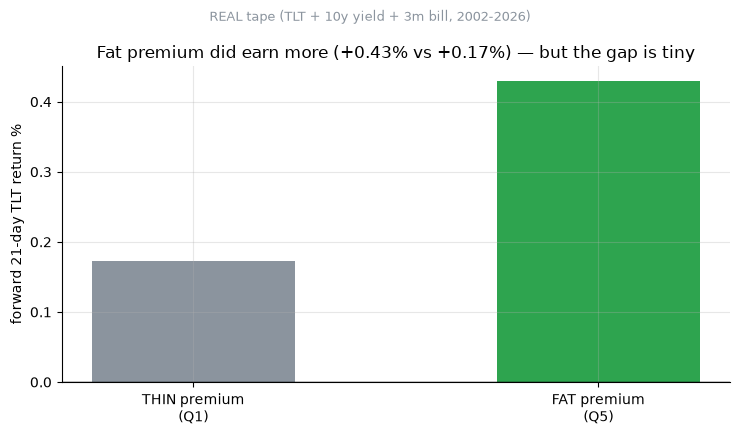

Thin +0.17%  vs  Fat +0.43%  ->  spread +0.26% (HAC t +0.43)


In [2]:
if HAVE_REAL:
    qs = st.quintile_spread(DF, horizon=21)
    q1, q5, spr, t = qs['q1']*100, qs['q5']*100, qs['spread']*100, qs['t']
    banner = 'REAL tape (TLT + 10y yield + 3m bill, 2002-2026)'
else:
    q1, q5, spr, t = 0.17, 0.43, 0.26, 0.43
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['THIN premium\n(Q1)','FAT premium\n(Q5)'], [q1, q5], color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 21-day TLT return %')
ax.set_title(f'Fat premium did earn more (+{q5:.2f}% vs +{q1:.2f}%) — but the gap is tiny')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Thin +{q1:.2f}%  vs  Fat +{q5:.2f}%  ->  spread {spr:+.2f}% (HAC t {t:+.2f})')

So the direction is **right**: the fat-premium days earned **+0.43%** over the next month vs **+0.17%** for the thin-premium days, a **+0.26%** edge. But look at the size — a quarter of a percent, with a *t*-stat of just **+0.43** (you want ≥ 2). That's a whisper.

**Does the whisper hold across the decades?** Run the same sort within four separate sub-periods:

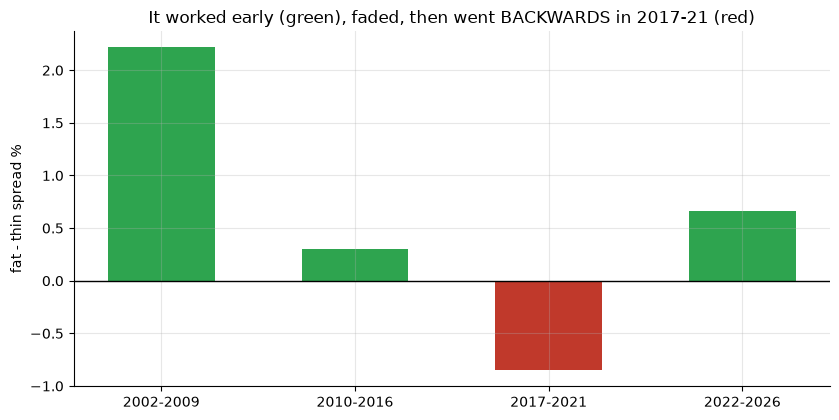

spreads by period: [2.22, 0.3, -0.85, 0.66]


In [3]:
sub = [('2002-2009', 2.22), ('2010-2016', 0.3), ('2017-2021', -0.85), ('2022-2026', 0.66)]
if HAVE_REAL:
    edges = [('2002-2009','2002-07-01','2009-12-31'),('2010-2016','2010-01-01','2016-12-31'),
             ('2017-2021','2017-01-01','2021-12-31'),('2022-2026','2022-01-01','2026-06-26')]
    tab = st.subperiod_sweep(DF, edges, horizon=21)
    labs = list(tab.index); spr = list(tab['spread']*100)
else:
    labs = [s[0] for s in sub]; spr = [s[1] for s in sub]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in spr]
ax.bar(labs, spr, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('fat - thin spread %')
ax.set_title('It worked early (green), faded, then went BACKWARDS in 2017-21 (red)')
plt.tight_layout(); plt.show()
print('spreads by period:', [round(s,2) for s in spr])

There's the catch. The premium timed bonds nicely in **2002-2009** (that's the only window that clears the bar), faded to nothing in **2010-2016**, and then *inverted* in **2017-2021** — the zero-rates era, when the premium barely moved and carried little information. A signal that changes its mind by decade isn't something you can bet the house on.

## 5 · The verdict

- **Signal — Weak.** Right direction (+0.26% fat-minus-thin) but a faint HAC *t* of +0.43, and the sign flips across decades. The theory is solid; this cheap estimate on this tape can't certify it.
- **Tradability — Mirage.** A timer on the signal barely ties buy-and-hold while churning ~10 times a year (next notebook).
- **Term-premium times duration? — Mixed.** Yes in 2002-09, no after.

## 6 · Could you actually trade it?

Barely, and not worth it. A timer that owns TLT only on fat-premium days sits in cash more than half the time — so it looks *smoother* (a slightly better Sharpe) but doesn't actually earn more; on the honest measure (average return) it *loses* to plain buy-and-hold, after flipping in and out ~10 times a year. The next notebook does the cost maths.

## 7 · Going further 🚪

- **The raw-slope cousin.** [132 Yield-Curve-Steepener](../../132-yield-curve-steepener/) uses the plain 10y−3m slope; this study strips out the expectations part to isolate the *premium*.
- **The real ACM series.** Re-run this with the actual NY-Fed ACM term premium (a CSV, not a free ticker) and a full cycle — that's the proper test.

*Think the premium really times bonds and we just used too crude an estimate? Fork this, drop in the ACM series, and show the fat-minus-thin spread clearing t = 2 out of sample.*